# CarDekho Dataset — EDA & Cleaning
**Author:** Hemanth  
**Date:** June 2026  
**Goal:** Clean and explore the CarDekho used car dataset to find pricing insights.

## Key Findings:
1. Maruti is the most represented brand in the used car market, indicating its strong market presence and high resale activity. Hyundai and Honda are the next most common brands.
2. Petrol vehicles constitute the largest share of listings, followed by Diesel vehicles. Alternative fuel vehicles such as CNG and LPG represent only a small portion of the market.
3. Manual transmission vehicles significantly outnumber automatic vehicles, suggesting that the used car market is still largely driven by manually operated cars.
4. Selling price shows a strong positive correlation with maximum power and vehicle age (newer vehicles), while kilometers driven has a negative correlation with selling price.
5. Luxury vehicles retain relatively high resale values even with higher mileage, unlike economy vehicles whose prices decline rapidly as kilometers driven increase.

In [1]:
import pandas as pd

In [2]:
#First import pandas, read a dataset using pandas library
cars = pd.read_csv("used_cars_messy.csv")

In [3]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15661 non-null  int64  
 1   car_name           15661 non-null  object 
 2   brand              15661 non-null  object 
 3   model              15661 non-null  object 
 4   vehicle_age        15661 non-null  int64  
 5   km_driven          15661 non-null  object 
 6   seller_type        15661 non-null  object 
 7   fuel_type          15661 non-null  object 
 8   transmission_type  15661 non-null  object 
 9   mileage            14376 non-null  object 
 10  engine             13792 non-null  float64
 11  max_power          14862 non-null  float64
 12  seats              15218 non-null  float64
 13  selling_price      15503 non-null  float64
dtypes: float64(4), int64(2), object(8)
memory usage: 1.7+ MB


In [4]:
# # Columns:-
# # 1) Unnamed:0 --> it doesn't have any meaningful name but doesn't have nulls and int is the datatype...we can remove or else rename the column
#                --> this column has 250 duplicates we can remove the duplicates. By default it will be keep first occurance, if we want we can keep last occurance Also

# # 2)

In [5]:
cars['Unnamed: 0'].nunique()

15411

In [65]:
cars[cars['Unnamed: 0'].duplicated(keep=False)].sort_values(by='Unnamed: 0')

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
10987,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.0,NaN,80.0,5.0,215000.0
10451,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.0,NaN,80.0,5.0,215000.0
10695,40,Maruti Swift Dzire,Maruti,Swift Dzire,8,90000,Individual,Diesel,Manual,23.4,1248.0,74.0,5.0,380000.0
6052,40,Maruti Swift Dzire,Maruti,Swift Dzire,8,90000,Individual,Diesel,Manual,23.4,1248.0,74.0,5.0,380000.0
3131,138,Mahindra Scorpio,Mahindra,Scorpio,4,30000,Dealer,Diesel,Manual,15.4,1997.0,120.0,7.0,1125000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1054,19309,Mahindra KUV,Mahindra,KUV,3,50000,Individual,CNG,Manual,18.15,1198.0,82.0,6.0,400000.0
13260,19345,Skoda Rapid,Skoda,Rapid,9,74000,Dealer,Diesel,Manual,20.5,NaN,103.5,5.0,351000.0
2720,19345,Skoda Rapid,Skoda,Rapid,9,74000,Dealer,Diesel,Manual,20.5,NaN,103.5,5.0,351000.0
329,19379,Maruti Baleno,Maruti,Baleno,5,34743,Dealer,Petrol,Automatic,21.4,1197.0,83.1,5.0,750000.0


In [62]:
cars[cars['Unnamed: 0'] == 18616]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
1577,18616,Maruti Ertiga,Maruti,Ertiga,6,75000,Dealer,Diesel,Manual,25.47,1248.0,88.5,NaN,650000.0
11950,18616,Maruti Ertiga,Maruti,Ertiga,6,75000,Dealer,Diesel,Manual,25.47,1248.0,88.5,NaN,650000.0


In [70]:
cars['Unnamed: 0'].value_counts()[lambda x:x>1]

,count
Unnamed: 0,
10176,2
19284,2
9712,2
4543,2
18230,2
...,...
8576,2
18616,2
6224,2


In [76]:
from numpy import dtype
x = cars['Unnamed: 0'].value_counts()

In [79]:
cars = cars.rename(columns={'Unnamed: 0' : 'srl_no'})
cars

,srl_no,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,6581,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,17029,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,6839,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,1104,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [6]:
cars.drop_duplicates()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,6581,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,17029,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,6839,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,1104,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [7]:
cars

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,6581,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,17029,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,6839,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,1104,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [83]:
len(cars.drop_duplicates())

15492

In [84]:
cars.duplicated().sum()

np.int64(169)

In [91]:
cars[cars['srl_no'].duplicated()]

,srl_no,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
1129,14596,Maruti Alto,Maruti,Alto,2,25000,Individual,Petrol,Manual,24.7,796.0,47.3,5.0,300000.0
1258,3691,Maruti Alto,Maruti,Alto,11,29000,Dealer,Petrol,Manual,19.7,796.0,46.3,5.0,175000.0
1349,2800,Hyundai i10,Hyundai,i10,13,45000,Dealer,Petrol,Manual,19.81,1086.0,NaN,5.0,210000.0
1356,4246,Tata Safari,Tata,Safari,9,100000,Individual,Diesel,Manual,11.57,2179.0,138.1,7.0,260000.0
1718,5151,Maruti Swift,Maruti,Swift,7,81000,Dealer,Diesel,Manual,28.4,1248.0,74.0,5.0,475000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15438,17972,Mahindra XUV500,Mahindra,XUV500,8,95000,Dealer,Diesel,Manual,15.1,2179.0,140.0,7.0,825000.0
15514,4543,Toyota Innova,Toyota,Innova,12,200000,Individual,Diesel,Manual,12.8,2494.0,102.0,7.0,480000.0
15524,18228,Mahindra XUV500,Mahindra,XUV500,9,80000,Individual,Diesel,Manual,15.1,2179.0,140.0,7.0,875000.0
15595,13064,Hyundai Verna,Hyundai,Verna,7,70000,Individual,Petrol,Manual,17.01,1591.0,121.3,5.0,610000.0


In [8]:
cars.drop(columns=['Unnamed: 0'],inplace=True)

In [9]:
cars.drop_duplicates(inplace=True)

In [10]:
cars

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [11]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15413 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15413 non-null  object 
 1   brand              15413 non-null  object 
 2   model              15413 non-null  object 
 3   vehicle_age        15413 non-null  int64  
 4   km_driven          15413 non-null  object 
 5   seller_type        15413 non-null  object 
 6   fuel_type          15413 non-null  object 
 7   transmission_type  15413 non-null  object 
 8   mileage            14144 non-null  object 
 9   engine             13566 non-null  float64
 10  max_power          14625 non-null  float64
 11  seats              14974 non-null  float64
 12  selling_price      15258 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.6+ MB


In [104]:
cars['car_name'].nunique()

121

In [105]:
cars['car_name'] = cars['car_name'].str.title()

In [106]:
cars['car_name'].nunique()

120

In [115]:
cars[['car_name','brand','model']].sample(20)

,car_name,brand,model
1628,Renault Triber,Renault,Triber
4721,Toyota Innova,Toyota,Innova
1601,Maruti Ignis,Maruti,Ignis
7902,Maruti Ertiga,Maruti,Ertiga
8488,Maruti Swift Dzire,Maruti,Swift Dzire
11799,Hyundai Creta,Hyundai,Creta
4229,Hyundai Santro,Hyundai,Santro
15237,Bmw 3,BMW,3
566,Hyundai Verna,Hyundai,Verna
1756,Maruti Vitara,Maruti,Vitara


In [116]:
temp = cars['brand'] + ' ' + cars['model']

(temp == cars['car_name']).all()

np.False_

In [122]:
mask = (cars['brand'] + ' ' + cars['model']) != cars['car_name']
mask
#cars.loc[mask, ['brand', 'model', 'car_name']]

,0
0,False
1,False
2,False
3,False
4,True
...,...
15656,False
15657,False
15658,False
15659,True


In [12]:
cars.drop(columns=['car_name'],inplace=True)

In [13]:
cars

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
15656,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [14]:
cars['brand'].nunique()

80

In [15]:
cars['brand'] = cars['brand'].str.strip().str.title()

In [16]:
cars['brand'].nunique()

31

In [17]:
cars['brand'].unique()

array(['Renault', 'Maruti', 'Honda', 'Mahindra', 'Hyundai', 'Ford',
       'Jeep', 'Bmw', 'Jaguar', 'Skoda', 'Volkswagen', 'Tata',
       'Mercedes-Benz', 'Datsun', 'Audi', 'Lexus', 'Toyota', 'Nissan',
       'Land Rover', 'Mini', 'Volvo', 'Porsche', 'Kia', 'Mg', 'Isuzu',
       'Mercedes-Amg', 'Ferrari', 'Bentley', 'Maserati', 'Force',
       'Rolls-Royce'], dtype=object)

In [18]:
cars['brand'] = cars['brand'].replace({
    'Bmw' : 'BMW',
    'Kia' : 'KIA',
    'Mg' : 'MG',
    'Isuzu' : 'ISUZU'
})

In [19]:
cars['model'].nunique()

120

In [20]:
cars['model'].unique()

array(['Duster', 'Wagon R', 'City', 'Scorpio', 'XUV500', 'i10', 'i20',
       'Freestyle', 'Swift Dzire', 'Swift', 'Grand', 'Compass', 'Figo',
       'Ertiga', 'Ciaz', 'Verna', 'Vitara', 'Civic', 'Creta', 'Venue',
       '3', 'Santro', 'Amaze', 'XF', 'Alto', 'Eeco', 'Rapid', 'Polo',
       'Jazz', 'Tiago', 'E-Class', 'Safari', 'Bolero', 'S-Presso',
       'RediGO', 'KUV', 'WR-V', 'Vento', 'A4', 'Elantra', 'S-Class',
       'redi-GO', 'Ecosport', 'A6', 'C-Class', 'Nexon', 'ES', 'KUV100',
       'Innova', 'X5', 'Celerio', 'Baleno', 'Endeavour', 'KWID', 'Aspire',
       'Fortuner', '5', 'CLS', 'Ignis', 'Kicks', 'Superb', 'Hexa', 'Thar',
       'GO', 'Tigor', 'Q7', 'A8', 'CR-V', 'Octavia', 'Rover', 'Dzire LXI',
       'GL-Class', 'Cooper', 'Camry', 'XC60', '6', 'Cayenne', 'X1',
       'Carnival', 'Hector', 'Marazzo', 'F-PACE', 'X4', 'Dzire VXI', 'Z4',
       '7', 'D-Max', 'XL6', 'Triber', 'Harrier', 'RX', 'X3', 'Seltos',
       'GLS', 'Glanza', 'MUX', 'XUV300', 'Yaris', 'NX', 'Alturas', 'X

In [21]:
cars[cars['model'] == 'redi-GO']

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
100,Datsun,redi-GO,3,6000,Dealer,Petrol,Automatic,22.0,999.0,67.05,5.0,435000.0
1311,Datsun,redi-GO,5,7001,Dealer,Petrol,Manual,21.7,NaN,67.05,5.0,325000.0
4828,Datsun,redi-GO,5,47000,Dealer,Petrol,Manual,20.71,799.0,53.64,5.0,299000.0
5453,Datsun,redi-GO,4,34000,DEALER,Petrol,Manual,NaN,999.0,67.05,5.0,249000.0
6685,Datsun,redi-GO,5,50000 km,Dealer,Petrol,Manual,21.7,999.0,67.05,5.0,325000.0
8855,Datsun,redi-GO,4,17000,Dealer,Petrol,Manual,20.71,799.0,53.64,5.0,280000.0
9312,Datsun,redi-GO,3,2300,Dealer,Petrol,Manual,20.71,799.0,53.64,5.0,325000.0
10081,Datsun,redi-GO,3,5986,Dealer,Petrol,Automatic,22.0,999.0,67.05,5.0,375000.0
13223,Datsun,redi-GO,4,50500,Dealer,Petrol,Manual,20.71,799.0,53.64,5.0,250000.0
15137,Datsun,redi-GO,1,10000,Dealer,Petrol,Manual,20.71,799.0,53.64,5.0,349000.0


In [22]:
cars['model'].value_counts()

,count
model,
i20,905
Swift Dzire,889
Swift,782
Alto,776
City,755
...,...
Altroz,1
Ghibli,1
Gurkha,1


In [23]:
cars[cars['model'].isin(['3','5','6','7'])][['brand','model']]

,brand,model
33,BMW,3
40,BMW,3
72,BMW,3
90,BMW,3
106,BMW,3
...,...,...
15279,BMW,7
15328,BMW,3
15412,BMW,3
15457,BMW,5


In [24]:
cars[cars['model'].isin(['CR','CR-V'])]

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
551,Honda,CR-V,14,155000,Dealer,Petrol,Automatic,10.1,NaN,152.00,5.0,475000.0
1717,Honda,CR-V,14,152358,Dealer,Petrol,Automatic,10.1,2354.0,152.00,5.0,600000.0
2556,Honda,CR-V,4,34000,Dealer,Petrol,Automatic,12.0,2354.0,187.40,5.0,1775000.0
2613,Honda,CR-V,4,55000,Dealer,Petrol,Automatic,13.7,1997.0,153.86,5.0,1750000.0
2757,Honda,CR-V,4,55000,Dealer,Petrol,Automatic,11.1,2354.0,158.80,NaN,1750000.0
3182,Honda,CR-V,13,120000,Dealer,Petrol,Automatic,10.1,2354.0,152.00,5.0,600000.0
3954,Honda,CR,4,75000,Dealer,Petrol,Automatic,12.0,2354.0,187.40,5.0,1750000.0
4019,Honda,CR,8,55000,Dealer,Petrol,Automatic,NaN,2354.0,187.40,5.0,890000.0
4918,Honda,CR-V,14,87000,Dealer,Petrol,Manual,10.8,2354.0,152.00,NaN,475000.0
4927,Honda,CR-V,5,56000,Dealer,Petrol,Automatic,12.0,2354.0,187.40,5.0,1475000.0


In [25]:
cars[cars['model'].isin(['XC','XC60','XC90'])]

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
839,Volvo,XC60,8,95000,Dealer,Diesel,Automatic,14.7,1984.0,181.0,NaN,1600000.0
3070,Volvo,XC90,2,25500,Dealer,Diesel,Automatic,17.2,1969.0,235.0,7.0,6975000.0
4687,Volvo,XC,1,9000,Dealer,Diesel,Automatic,17.2,1969.0,235.0,7.0,8195000.0
5017,Volvo,XC60,6,120000,Dealer,Diesel,Automatic,11.2,2400.0,215.0,5.0,1800000.0
5800,Volvo,XC90,6,80000,Individual,Diesel,Automatic,17.2,1969.0,235.0,7.0,4350000.0
5971,Volvo,XC90,3,33000,Dealer,Diesel,Automatic,17.2,1969.0,235.0,7.0,5499000.0
7075,Volvo,XC60,9,99000,Dealer,Diesel,Automatic,14.7,NaN,163.0,5.0,1600000.0
7708,Volvo,XC60,7,70252,Dealer,Diesel,Automatic,11.2,2400.0,215.0,5.0,1825000.0
11007,Volvo,XC90,5,85000,Dealer,Diesel,Automatic,17.2,1969.0,235.0,NaN,4100000.0
12076,Volvo,XC,1,9500,Dealer,Diesel,Automatic,17.2,NaN,235.0,7.0,8000000.0


In [26]:
cars.groupby('model')['brand'].nunique().sort_values(ascending=False).tail(60)

,brand
model,
Innova,1
Jazz,1
KUV,1
KUV100,1
KWID,1
Kicks,1
MUX,1
Macan,1
Marazzo,1


In [27]:
cars[(cars['model'] == 'Swift Dzire') | (cars['model'] == 'Swift')]

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
9,Maruti,Swift Dzire,10,75220,Dealer,Diesel,Manual,19.3,1248.0,73.90,5.0,390000.0
10,Maruti,Swift,6,34000,Dealer,Petrol,Manual,16.1,1197.0,85.00,5.0,450000.0
14,Maruti,Swift,5,47350,Individual,Diesel,Manual,25.2,NaN,74.00,5.0,640000.0
16,Maruti,Swift Dzire,10,86000,Individual,Diesel,Manual,19.3,1248.0,73.90,5.0,420000.0
20,Maruti,Swift,5,130130,Dealer,Diesel,Manual,25.2,1248.0,74.00,5.0,400000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
15620,Maruti,Swift,7,56000,Dealer,Petrol,Manual,16.1,1197.0,NaN,5.0,401000.0
15623,Maruti,Swift Dzire,6,25000,Individual,Petrol,Manual,NaN,1197.0,83.14,5.0,460000.0
15626,Maruti,Swift Dzire,8,82000,Dealer,Diesel,Manual,23.4,1248.0,74.00,5.0,425000.0
15636,Maruti,Swift Dzire,13,95000,Dealer,Diesel,Manual,19.3,1248.0,73.90,5.0,310000.0


In [33]:
cars['model'] = cars['model'].replace({
    'CR' : 'CR-V'
})

In [34]:
cars['model'].unique()

array(['Duster', 'Wagon R', 'City', 'Scorpio', 'XUV500', 'i10', 'i20',
       'Freestyle', 'Swift Dzire', 'Swift', 'Grand', 'Compass', 'Figo',
       'Ertiga', 'Ciaz', 'Verna', 'Vitara', 'Civic', 'Creta', 'Venue',
       '3', 'Santro', 'Amaze', 'XF', 'Alto', 'Eeco', 'Rapid', 'Polo',
       'Jazz', 'Tiago', 'E-Class', 'Safari', 'Bolero', 'S-Presso',
       'RediGO', 'KUV', 'WR-V', 'Vento', 'A4', 'Elantra', 'S-Class',
       'redi-GO', 'Ecosport', 'A6', 'C-Class', 'Nexon', 'ES', 'KUV100',
       'Innova', 'X5', 'Celerio', 'Baleno', 'Endeavour', 'KWID', 'Aspire',
       'Fortuner', '5', 'CLS', 'Ignis', 'Kicks', 'Superb', 'Hexa', 'Thar',
       'GO', 'Tigor', 'Q7', 'A8', 'CR-V', 'Octavia', 'Rover', 'Dzire LXI',
       'GL-Class', 'Cooper', 'Camry', 'XC60', '6', 'Cayenne', 'X1',
       'Carnival', 'Hector', 'Marazzo', 'F-PACE', 'X4', 'Dzire VXI', 'Z4',
       '7', 'D-Max', 'XL6', 'Triber', 'Harrier', 'RX', 'X3', 'Seltos',
       'GLS', 'Glanza', 'MUX', 'XUV300', 'Yaris', 'NX', 'Alturas', 'X

In [30]:
cars.insert(
    0,
    'car_fullname',
    cars['brand'] + ' ' + cars['model']
)

In [31]:
cars[cars['car_fullname'] == 'Renault Duster']

,car_fullname,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
227,Renault Duster,Renault,Duster,2,7131,Dealer,Petrol,Automatic,14.99,1498.0,104.50,5.0,1099000.0
244,Renault Duster,Renault,Duster,5,62000 kms,Individual,Diesel,Manual,19.87,1461.0,83.80,5.0,700000.0
278,Renault Duster,Renault,Duster,2,19444,Dealer,Petrol,Automatic,NaN,1498.0,105.00,5.0,1140000.0
337,Renault Duster,Renault,Duster,8,88000,Dealer,Diesel,Manual,20.45,NaN,83.80,5.0,450000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15273,Renault Duster,Renault,Duster,6,93292,Dealer,Diesel,Manual,NaN,1461.0,108.45,5.0,690000.0
15615,Renault Duster,Renault,Duster,4,7489,Individual,Diesel,Manual,19.6,1461.0,108.45,5.0,900000.0
15640,Renault Duster,Renault,Duster,6,67000,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,510000.0
15643,Renault Duster,Renault,Duster,7,43001,Dealer,Diesel,Manual,19.01,1461.0,108.45,5.0,449000.0


In [35]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15413 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_fullname       15413 non-null  object 
 1   brand              15413 non-null  object 
 2   model              15413 non-null  object 
 3   vehicle_age        15413 non-null  int64  
 4   km_driven          15413 non-null  object 
 5   seller_type        15413 non-null  object 
 6   fuel_type          15413 non-null  object 
 7   transmission_type  15413 non-null  object 
 8   mileage            14144 non-null  object 
 9   engine             13566 non-null  float64
 10  max_power          14625 non-null  float64
 11  seats              14974 non-null  float64
 12  selling_price      15258 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.6+ MB


In [37]:
cars['vehicle_age'].unique()

array([ 7,  3,  6,  4, 12,  2, 10,  1,  5,  8, 11, 13,  9, 16, 14, 15, 17,
       18, 29, 25, 21,  0, 19, 22])

In [38]:
cars[cars['vehicle_age'] == 0]

,car_fullname,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
4758,BMW 5,BMW,5,0,2000,Dealer,Diesel,Automatic,22.48,1995.0,187.74,5.0,4850000.0
11925,Mahindra KUV,Mahindra,KUV,0,30000,Individual,petrol,Manual,18.15,NaN,82.00,6.0,400000.0
12665,Maruti Ignis,Maruti,Ignis,0,5000,Individual,Petrol,Manual,20.89,1197.0,81.80,5.0,550000.0
13404,Maruti S-Presso,Maruti,S-Presso,0,5000,Individual,Petrol,Manual,NaN,998.0,67.00,5.0,500000.0


In [39]:
cars.rename(columns={
    'vehicle_age':'vehicle_age(in years)'
},inplace=True)

In [67]:
cars[cars['km_driven'].str.contains('kms')]

,car_fullname,brand,model,vehicle_age(in years),km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [53]:
cars['km_driven'] = cars['km_driven'].replace({
    'km':'',
    'kms':''
})

TypeError: StringMethods.replace() missing 1 required positional argument: 'repl'

In [58]:
cars['km_driven'] = cars['km_driven'].replace({
    'kms':''
})

In [73]:
cars['km_driven'].unique()[:100]

array(['67647', '52000', '48959', '82000', '34000', '73000', '88000',
       '50000', '30000', '75220', '15000', '43726', '13000', '47350',
       '86000', '10983', '44000', '93000', '130130', '48000', '54000',
       '70000', '3700', '100000', '16000', '23000', '25000', '45000',
       '65000', '72000', '100', '68000', '80000', '60000', '95000',
       '7369', '104000', '97000', '64000', '63000', '93096', '58000',
       '12000', '94000', '31000', '105000', '24000', '120000', '33000',
       '42100', '45833', '5000', '9100', '103000', '11995', '110000',
       '26000', '42000', '57000', '78950', '83000', '33999', '22000',
       '16219', '69000', '20000', '78000', '98000', '53892', '20001',
       '40000', '6000', '71678', '114000', '38640', '56000', '32886',
       '32000', '37000', '29200', '15659', '14000', '90000', '52121',
       '71000', '43000', '55000', '10000', '45425', '35000', '46000',
       '51630', '36000', '62600', '50503', '29000', '53080', '37900',
       '29957', '56

In [65]:
cars['km_driven'] = cars['km_driven'].str.lower()

In [66]:
cars['km_driven'] = cars['km_driven'].str.replace(r'\s*kms?$', '', regex=True)

In [68]:
cars['km_driven'] = cars['km_driven'].str.replace(',','')

In [70]:
cars['km_driven'] = cars['km_driven'].str.replace(' ','')

In [71]:
cars['km_driven'] = cars['km_driven'].str.strip()

In [74]:
cars['km_driven'] = pd.to_numeric(cars['km_driven'])

In [78]:
cars['km_driven'].describe().apply(lambda x: f'{x:,.0f}')

,km_driven
count,"15,413"
mean,"55,595"
std,"51,627"
min,100
25%,"30,000"
50%,"50,000"
75%,"70,000"
max,"3,800,000"


In [79]:
cars[cars['km_driven'] == 3800000]

,car_fullname,brand,model,vehicle_age(in years),km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
11709,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,diesel,Manual,16.0,2179.0,140.0,7.0,1225000.0


In [80]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15413 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   car_fullname           15413 non-null  object 
 1   brand                  15413 non-null  object 
 2   model                  15413 non-null  object 
 3   vehicle_age(in years)  15413 non-null  int64  
 4   km_driven              15413 non-null  int64  
 5   seller_type            15413 non-null  object 
 6   fuel_type              15413 non-null  object 
 7   transmission_type      15413 non-null  object 
 8   mileage                14144 non-null  object 
 9   engine                 13566 non-null  float64
 10  max_power              14625 non-null  float64
 11  seats                  14974 non-null  float64
 12  selling_price          15258 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 1.6+ MB


In [89]:
cars['seller_type'].unique()

array(['Dealer', 'Individual', 'Trustmark Dealer'], dtype=object)

In [85]:
cars['seller_type'] = cars['seller_type'].str.strip().str.title()

In [88]:
cars['seller_type'] = cars['seller_type'].replace({
    'Individul' : 'Individual',
    'Individuall' : 'Individual',
    'Delaer' : 'Dealer'
})

In [96]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15413 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   car_fullname           15413 non-null  object 
 1   brand                  15413 non-null  object 
 2   model                  15413 non-null  object 
 3   vehicle_age(in years)  15413 non-null  int64  
 4   km_driven              15413 non-null  int64  
 5   seller_type            15413 non-null  object 
 6   fuel_type              15413 non-null  object 
 7   transmission_type      15413 non-null  object 
 8   mileage                14144 non-null  object 
 9   engine                 13566 non-null  float64
 10  max_power              14625 non-null  float64
 11  seats                  14974 non-null  float64
 12  selling_price          15258 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 1.6+ MB


In [95]:
cars['fuel_type'].unique()

array(['Diesel', 'CNG', 'Petrol', 'LPG', 'Electric'], dtype=object)

In [92]:
cars['fuel_type'] = cars['fuel_type'].str.strip().str.title()

In [94]:
cars['fuel_type'] = cars['fuel_type'].replace({
    'Cng' : 'CNG',
    'Lpg' : 'LPG'
})

In [99]:
cars['transmission_type'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [98]:
cars['transmission_type'] = cars['transmission_type'].str.strip()

In [115]:
cars['mileage'].unique()[:]

array([19.87, 33.54,   nan, 15.4 , 16.  , 20.36, 18.5 , 20.51, 24.4 ,
       19.3 , 16.1 , 17.1 , 18.9 , 25.2 , 21.5 , 20.  , 17.  , 28.09,
       23.9 , 22.54, 24.3 , 14.8 , 18.6 , 21.38, 18.27, 26.6 , 21.76,
       20.3 , 24.7 , 23.95, 22.  , 19.7 , 15.37, 20.5 , 23.4 , 16.2 ,
       18.7 , 23.84, 17.4 , 14.21, 19.2 , 20.65, 16.8 , 22.74, 15.  ,
       14.1 , 20.77, 16.5 , 19.59, 21.7 , 27.3 , 22.7 , 24.52, 15.1 ,
       22.32, 18.15, 30.46, 22.9 , 12.3 , 25.5 , 17.69, 22.69, 16.55,
       25.47, 19.5 , 13.  , 22.1 , 13.5 , 17.8 , 23.  , 19.  , 16.07,
       24.  , 20.14, 20.4 , 17.21, 21.21, 15.63, 17.68, 26.2 , 19.67,
       19.27, 14.  , 20.73, 17.5 , 22.37, 21.72, 26.59, 17.92, 18.19,
       22.77, 12.99, 19.1 , 25.8 , 23.1 , 15.96, 19.56, 20.85, 14.62,
       11.57, 21.4 , 17.01, 16.36, 11.2 , 21.66, 13.68, 16.47, 25.17,
       22.27, 25.83, 27.39, 15.9 , 12.9 , 16.09, 26.82, 20.54, 13.93,
       22.48, 18.  , 26.8 , 14.99, 32.52, 11.74, 15.97, 20.7 , 13.6 ,
       22.07, 21.79,

In [109]:
cars['mileage'] = cars['mileage'].str.strip()

In [111]:
cars['mileage'] = cars['mileage'].str.replace(r'\s*kmpl$','',regex=True)

In [113]:
cars['mileage'] = pd.to_numeric(cars['mileage'],errors='coerce')

In [114]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15413 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   car_fullname           15413 non-null  object 
 1   brand                  15413 non-null  object 
 2   model                  15413 non-null  object 
 3   vehicle_age(in years)  15413 non-null  int64  
 4   km_driven              15413 non-null  int64  
 5   seller_type            15413 non-null  object 
 6   fuel_type              15413 non-null  object 
 7   transmission_type      15413 non-null  object 
 8   mileage                14144 non-null  float64
 9   engine                 13566 non-null  float64
 10  max_power              14625 non-null  float64
 11  seats                  14974 non-null  float64
 12  selling_price          15258 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.6+ MB


In [116]:
cars['mileage'].describe()

,mileage
count,14144.000000
mean,19.703526
std,4.176020
min,4.000000
25%,17.000000
50%,19.670000
75%,22.700000
max,33.540000


In [131]:
cars['mileage'].count()

np.int64(15413)

In [130]:
cars['mileage'].isna().sum()

np.int64(0)

In [119]:
(1269/14144) * 100

8.97200226244344

In [122]:
cars[cars['mileage'].isna()].head(10)

,car_fullname,brand,model,vehicle_age(in years),km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
2,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
11,Hyundai Grand,Hyundai,Grand,1,15000,Individual,Petrol,Manual,NaN,1197.0,81.86,5.0,511000.0
22,Maruti Ertiga,Maruti,Ertiga,7,54000,Dealer,CNG,Manual,NaN,NaN,80.90,7.0,675000.0
35,Hyundai Grand,Hyundai,Grand,7,15000,Individual,Petrol,Manual,NaN,1197.0,82.00,5.0,500000.0
39,Jaguar XF,Jaguar,XF,6,60000,Individual,Diesel,Automatic,NaN,2179.0,187.70,5.0,2400000.0
40,BMW 3,BMW,3,11,95000,Dealer,Diesel,Automatic,NaN,NaN,170.00,5.0,1040000.0
78,Maruti Alto,Maruti,Alto,4,26000,Dealer,CNG,Manual,NaN,NaN,40.30,4.0,300000.0
102,Maruti Ertiga,Maruti,Ertiga,4,44000,Dealer,Diesel,Manual,NaN,1248.0,88.50,7.0,725000.0
103,Honda City,Honda,City,6,71678,Dealer,Diesel,Manual,NaN,1498.0,98.60,5.0,610000.0
110,Hyundai i10,Hyundai,i10,5,32886,Dealer,Petrol,Manual,NaN,1197.0,78.90,5.0,449000.0


In [127]:
cars.groupby('fuel_type')['mileage'].median()

,mileage
fuel_type,
CNG,26.60
Diesel,20.50
Electric,19.16
LPG,17.30
Petrol,18.90


In [128]:
cars.groupby('model')['mileage'].median()

,mileage
model,
3,18.88
5,18.12
6,14.28
7,16.46
A4,16.55
...,...
Yaris,17.80
Z4,10.37
i10,20.36


In [129]:
#Replacing the NaN values of mileage with median of respective fuel_type
cars['mileage'] = cars.groupby('fuel_type')['mileage'].transform(lambda x : x.fillna(x.median()))

In [132]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15413 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   car_fullname           15413 non-null  object 
 1   brand                  15413 non-null  object 
 2   model                  15413 non-null  object 
 3   vehicle_age(in years)  15413 non-null  int64  
 4   km_driven              15413 non-null  int64  
 5   seller_type            15413 non-null  object 
 6   fuel_type              15413 non-null  object 
 7   transmission_type      15413 non-null  object 
 8   mileage                15413 non-null  float64
 9   engine                 13566 non-null  float64
 10  max_power              14625 non-null  float64
 11  seats                  14974 non-null  float64
 12  selling_price          15258 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.6+ MB


In [138]:
cars['engine'].unique()

array([1461.,  998., 1497., 2179., 1197.,   nan, 1498., 1248., 1956.,
       1399., 1298., 1582., 1396.,  796., 1997., 1196., 1598., 1199.,
       1462., 1991., 1493.,  799., 1198., 1796., 2523.,  999., 1995.,
       1968., 2143., 2987., 1120., 1499., 1373., 2487., 1086., 2494.,
       2993., 1999., 3198., 1591., 2497., 2393., 1496., 2755., 1950.,
       1186., 1798., 2997., 2982., 2967., 1368., 4134., 1047., 1599.,
       1998., 2694., 4367., 1799., 2498., 1194.,  793., 1984., 2092.,
       1061., 2199., 2499., 2148., 1896., 1797., 2998., 3498., 2354.,
       3456., 1781., 1353., 2996., 1343., 2698., 2999., 3628., 2609.,
       2979., 2362., 5461., 1451., 2157., 1969., 3604., 2995., 4395.,
       1395., 2953., 2400., 4663., 3597., 1590., 1330., 2198., 3855.,
       2771., 5998., 3598., 2495., 4806., 4163., 1597., 2596., 2773.,
       1985., 6592.])

In [141]:
cars['engine'].isna().sum()

np.int64(0)

In [139]:
cars['engine'].isna().mean() * 100
# 11.9 percent missing values

np.float64(11.983390644261338)

In [140]:
# Replacing the engine value with median of specific model
cars['engine'] = cars.groupby('model')['engine'].transform(lambda x : x.fillna(x.median()))

In [144]:
cars['engine'].describe()

,engine
count,15413.000000
mean,1484.653247
std,518.352203
min,793.000000
25%,1197.000000
50%,1248.000000
75%,1582.000000
max,6592.000000


In [142]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15413 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   car_fullname           15413 non-null  object 
 1   brand                  15413 non-null  object 
 2   model                  15413 non-null  object 
 3   vehicle_age(in years)  15413 non-null  int64  
 4   km_driven              15413 non-null  int64  
 5   seller_type            15413 non-null  object 
 6   fuel_type              15413 non-null  object 
 7   transmission_type      15413 non-null  object 
 8   mileage                15413 non-null  float64
 9   engine                 15413 non-null  float64
 10  max_power              14625 non-null  float64
 11  seats                  14974 non-null  float64
 12  selling_price          15258 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.6+ MB


In [143]:
cars['max_power'].unique()

array([ 83.8 ,  67.04, 117.6 ,    nan, 140.  ,  78.9 ,  80.  ,  98.63,
        73.9 ,  85.  ,  81.86, 173.  ,  82.  ,  74.  , 120.  ,  81.8 ,
        68.1 , 118.  ,  88.2 ,  80.9 ,  88.5 , 126.2 ,  88.73, 130.2 ,
        81.83,  88.7 , 118.35,  58.16, 188.  ,  68.  , 187.7 , 170.  ,
        67.05,  46.3 ,  73.  , 103.5 ,  67.1 ,  84.  , 203.  , 103.25,
        47.3 , 194.4 , 147.94,  88.76, 117.3 ,  70.  , 187.74,  67.  ,
        98.6 ,  53.64,  40.3 , 126.32, 185.  ,  75.  , 108.62, 190.  ,
       147.51, 126.24, 201.1 , 282.  ,  86.7 ,  98.96,  85.8 , 181.  ,
       110.4 , 174.33,  58.2 , 167.62, 138.1 ,  91.2 , 108.5 , 214.56,
        77.  , 108.6 ,  62.1 , 103.2 ,  98.59, 100.  , 235.  ,  88.8 ,
        83.14, 149.92,  83.1 , 197.  , 121.3 , 138.13, 103.52, 147.8 ,
        53.3 ,  99.  , 120.69,  91.1 , 174.5 ,  93.87, 103.6 , 241.3 ,
       104.5 ,  58.33, 186.  , 258.  ,  73.97,  63.  , 100.6 , 116.3 ,
       104.55, 157.75, 153.86, 105.  ,  74.02, 116.4 ,  68.05, 181.03,
      

In [145]:
cars['max_power'].isna().sum()

np.int64(788)

In [147]:
cars['max_power'].isna().mean()*100

np.float64(5.112567313306949)

In [148]:
cars['max_power'].describe()

,max_power
count,14625.000000
mean,100.570360
std,42.939288
min,38.400000
25%,74.000000
50%,88.500000
75%,117.300000
max,626.000000


In [149]:
cars.sort_values('max_power', ascending=False)[
    ['brand', 'model', 'engine', 'max_power']
].head(20)

,brand,model,engine,max_power
8457,Bentley,Continental,5998.0,626.0
7340,Ferrari,GTC4Lusso,3855.0,601.0
14617,Bentley,Continental,5998.0,600.0
15371,Rolls-Royce,Ghost,6592.0,563.0
14110,Bentley,Continental,5998.0,552.0
11558,Porsche,Cayenne,4806.0,500.0
5089,Mercedes-Benz,S-Class,4663.0,459.0
4354,BMW,6,4395.0,450.0
8319,Porsche,Cayenne,3604.0,440.0
7006,Porsche,Cayenne,3604.0,420.0


In [151]:
#Replacing the max_power NaN values with median of specific values max_power
cars['max_power'] = cars.groupby('model')['max_power'].transform(lambda x : x.fillna(x.median()))

In [152]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15413 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   car_fullname           15413 non-null  object 
 1   brand                  15413 non-null  object 
 2   model                  15413 non-null  object 
 3   vehicle_age(in years)  15413 non-null  int64  
 4   km_driven              15413 non-null  int64  
 5   seller_type            15413 non-null  object 
 6   fuel_type              15413 non-null  object 
 7   transmission_type      15413 non-null  object 
 8   mileage                15413 non-null  float64
 9   engine                 15413 non-null  float64
 10  max_power              15413 non-null  float64
 11  seats                  14974 non-null  float64
 12  selling_price          15258 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.6+ MB


In [153]:
cars['seats'].unique()

array([ 5.,  8.,  7., nan,  4.,  6.,  9.,  2.,  0.])

In [158]:
cars[cars['seats'] == 9]

,car_fullname,brand,model,vehicle_age(in years),km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
265,Mahindra Bolero,Mahindra,Bolero,7,225000,Individual,Diesel,Manual,15.96,2523.0,63.0,9.0,380000.0
287,Mahindra Bolero,Mahindra,Bolero,7,120000,Individual,Diesel,Manual,15.96,2523.0,62.1,9.0,500000.0
713,Mahindra Scorpio,Mahindra,Scorpio,8,67000,Dealer,Diesel,Manual,15.40,2179.0,120.0,9.0,550000.0
1225,Mahindra Bolero,Mahindra,Bolero,4,90000,Individual,Diesel,Manual,20.50,2523.0,63.0,9.0,750000.0
1856,Mahindra Scorpio,Mahindra,Scorpio,7,70000,Individual,Diesel,Manual,12.05,2179.0,120.0,9.0,595000.0
2381,Mahindra Bolero,Mahindra,Bolero,6,72658,Dealer,Diesel,Manual,15.96,2523.0,63.0,9.0,480000.0
2674,Mahindra Bolero,Mahindra,Bolero,6,120000,Individual,Diesel,Manual,15.96,2523.0,63.0,9.0,473000.0
3284,Mahindra Scorpio,Mahindra,Scorpio,7,30000,Dealer,Diesel,Manual,15.40,1997.0,120.0,9.0,400000.0
3334,Mahindra Scorpio,Mahindra,Scorpio,10,130311,Dealer,Diesel,Manual,12.05,2179.0,120.0,9.0,385000.0
3430,Mahindra Scorpio,Mahindra,Scorpio,9,80000,Individual,Diesel,Manual,12.05,2179.0,120.0,9.0,600000.0


In [156]:
cars['seats'].value_counts(dropna=False)

,count
seats,
5.0,12559
7.0,1853
NaN,439
8.0,302
6.0,125
4.0,73
9.0,53
2.0,7
0.0,2


In [159]:
import numpy as np
cars['seats'] = cars['seats'].replace(0,np.nan)

In [167]:
cars['seats'].value_counts(dropna=False)

,count
seats,
5.0,12924
7.0,1925
8.0,302
6.0,129
4.0,73
9.0,53
2.0,7


In [166]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15413 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   car_fullname           15413 non-null  object 
 1   brand                  15413 non-null  object 
 2   model                  15413 non-null  object 
 3   vehicle_age(in years)  15413 non-null  int64  
 4   km_driven              15413 non-null  int64  
 5   seller_type            15413 non-null  object 
 6   fuel_type              15413 non-null  object 
 7   transmission_type      15413 non-null  object 
 8   mileage                15413 non-null  float64
 9   engine                 15413 non-null  float64
 10  max_power              15413 non-null  float64
 11  seats                  15413 non-null  float64
 12  selling_price          15258 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.6+ MB


In [169]:
#cars.groupby('model')['seats'].mode()
cars.groupby('model')['seats'].agg(lambda x: x.mode().iloc[0])

,seats
model,
3,5.0
5,5.0
6,4.0
7,5.0
A4,5.0
...,...
Yaris,5.0
Z4,2.0
i10,5.0


In [165]:
cars['seats'] = (
    cars.groupby('model')['seats']
        .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else x.median()))
)

In [170]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15413 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   car_fullname           15413 non-null  object 
 1   brand                  15413 non-null  object 
 2   model                  15413 non-null  object 
 3   vehicle_age(in years)  15413 non-null  int64  
 4   km_driven              15413 non-null  int64  
 5   seller_type            15413 non-null  object 
 6   fuel_type              15413 non-null  object 
 7   transmission_type      15413 non-null  object 
 8   mileage                15413 non-null  float64
 9   engine                 15413 non-null  float64
 10  max_power              15413 non-null  float64
 11  seats                  15413 non-null  float64
 12  selling_price          15258 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.6+ MB


In [171]:
cars['selling_price'].isna().sum()

np.int64(155)

In [172]:
cars['selling_price'].isna().mean()*100

np.float64(1.005644585739311)

In [173]:
cars['selling_price'].describe()

,selling_price
count,1.525800e+04
mean,1.037486e+06
std,1.620201e+07
min,5.000000e+02
25%,3.850000e+05
50%,5.550000e+05
75%,8.250000e+05
max,1.000000e+09


In [174]:
cars['selling_price'].describe().apply(lambda x: f'{x:,.0f}')

,selling_price
count,"15,258"
mean,"1,037,486"
std,"16,202,010"
min,500
25%,"385,000"
50%,"555,000"
75%,"825,000"
max,"999,999,999"


In [176]:
cars.nlargest(20, 'selling_price')[
    ['brand', 'model', 'selling_price']
]

,brand,model,selling_price
1460,Honda,City,999999999.0
1473,Maruti,Ertiga,999999999.0
12361,Hyundai,i20,999999999.0
13614,Maruti,Vitara,999999999.0
7340,Ferrari,GTC4Lusso,39500000.0
15371,Rolls-Royce,Ghost,24200000.0
8457,Bentley,Continental,14500000.0
5089,Mercedes-Benz,S-Class,13000000.0
8319,Porsche,Cayenne,11100000.0
5974,Mercedes-Benz,S-Class,11000000.0


In [177]:
cars[cars['selling_price'] > 50000000]

,car_fullname,brand,model,vehicle_age(in years),km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
1460,Honda City,Honda,City,11,59000,Individual,Petrol,Manual,17.00,1497.0,118.00,5.0,999999999.0
1473,Maruti Ertiga,Maruti,Ertiga,5,48805,Individual,Diesel,Manual,24.52,1248.0,88.76,7.0,999999999.0
12361,Hyundai i20,Hyundai,i20,5,27965,Dealer,Petrol,Manual,18.60,1197.0,81.83,5.0,999999999.0
13614,Maruti Vitara,Maruti,Vitara,3,35000,Dealer,Diesel,Manual,24.30,1248.0,88.50,5.0,999999999.0


In [179]:
cars.nsmallest(20, 'selling_price')[
    ['brand', 'model', 'selling_price']
]

,brand,model,selling_price
4000,Toyota,Innova,500.0
5890,Maruti,Ciaz,500.0
6411,Volkswagen,Vento,500.0
10418,Hyundai,Creta,500.0
9098,Maruti,Wagon R,40000.0
3608,Maruti,Alto,45000.0
7376,Maruti,Alto,50000.0
10911,Honda,City,50000.0
14202,Maruti,Wagon R,50000.0
2460,Maruti,Wagon R,55000.0


In [187]:
cars = cars.dropna(subset='selling_price')

In [188]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15250 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   car_fullname           15250 non-null  object 
 1   brand                  15250 non-null  object 
 2   model                  15250 non-null  object 
 3   vehicle_age(in years)  15250 non-null  int64  
 4   km_driven              15250 non-null  int64  
 5   seller_type            15250 non-null  object 
 6   fuel_type              15250 non-null  object 
 7   transmission_type      15250 non-null  object 
 8   mileage                15250 non-null  float64
 9   engine                 15250 non-null  float64
 10  max_power              15250 non-null  float64
 11  seats                  15250 non-null  float64
 12  selling_price          15250 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.6+ MB


In [186]:
cars.nsmallest(5,'selling_price')

,car_fullname,brand,model,vehicle_age(in years),km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
9098,Maruti Wagon R,Maruti,Wagon R,21,80000,Individual,Petrol,Manual,18.9,998.0,67.1,5.0,40000.0
3608,Maruti Alto,Maruti,Alto,17,110000,Individual,Petrol,Manual,19.7,796.0,46.3,5.0,45000.0
7376,Maruti Alto,Maruti,Alto,19,120000,Individual,Petrol,Manual,18.9,1061.0,47.0,5.0,50000.0
10911,Honda City,Honda,City,19,110000,Individual,Petrol,Manual,13.0,1493.0,100.0,5.0,50000.0
14202,Maruti Wagon R,Maruti,Wagon R,17,50000,Individual,Petrol,Manual,18.9,998.0,67.1,5.0,50000.0


In [184]:
cars['selling_price'] = cars['selling_price'].replace({500.0:np.nan,999999999.0:np.nan})

/tmp/ipykernel_2383/3691417262.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cars['selling_price'] = cars['selling_price'].replace({500.0:np.nan,999999999.0:np.nan})


In [189]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15250 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   car_fullname           15250 non-null  object 
 1   brand                  15250 non-null  object 
 2   model                  15250 non-null  object 
 3   vehicle_age(in years)  15250 non-null  int64  
 4   km_driven              15250 non-null  int64  
 5   seller_type            15250 non-null  object 
 6   fuel_type              15250 non-null  object 
 7   transmission_type      15250 non-null  object 
 8   mileage                15250 non-null  float64
 9   engine                 15250 non-null  float64
 10  max_power              15250 non-null  float64
 11  seats                  15250 non-null  float64
 12  selling_price          15250 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.6+ MB


In [190]:
cars.to_csv("cars_cleaned.csv",index=False)

In [ ]:
# 1. Basic stats
print(df.describe())

# 2. Most popular car brands
df['brand'].value_counts().plot(kind='bar', title='Cars by Brand')

# 3. Average selling price by fuel type
df.groupby('fuel_type')['selling_price'].mean().sort_values()

# 4. Manual vs Automatic — which sells more expensive?
df.groupby('transmission')['selling_price'].mean()

# 5. Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Greens')
plt.show()

<Axes: title={'center': 'Cars by Brand'}, xlabel='brand'>

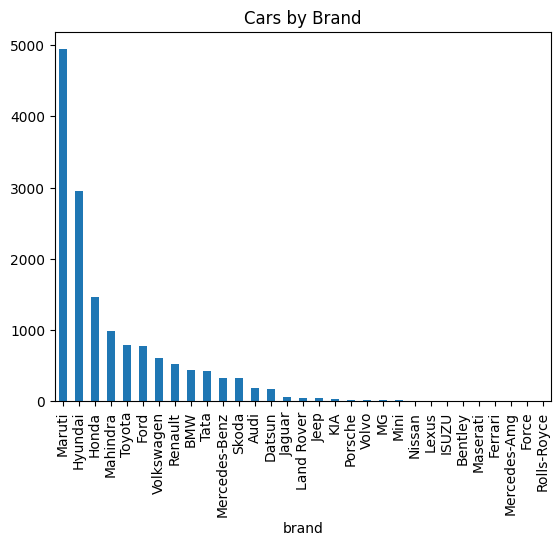

In [191]:
# 2. Most popular car brands
cars['brand'].value_counts().plot(kind='bar', title='Cars by Brand')

In [193]:
cars.groupby('fuel_type')['selling_price'].mean().sort_values().apply(lambda x: f'{x:,.0f}')

,selling_price
fuel_type,
LPG,"205,578"
CNG,"419,895"
Petrol,"572,071"
Diesel,"1,003,211"
Electric,"1,853,500"


In [198]:
cars.groupby('transmission_type')['selling_price'].mean().apply(lambda x : f'{x:,.0f}')

,selling_price
transmission_type,
Automatic,"1,580,998"
Manual,"565,345"


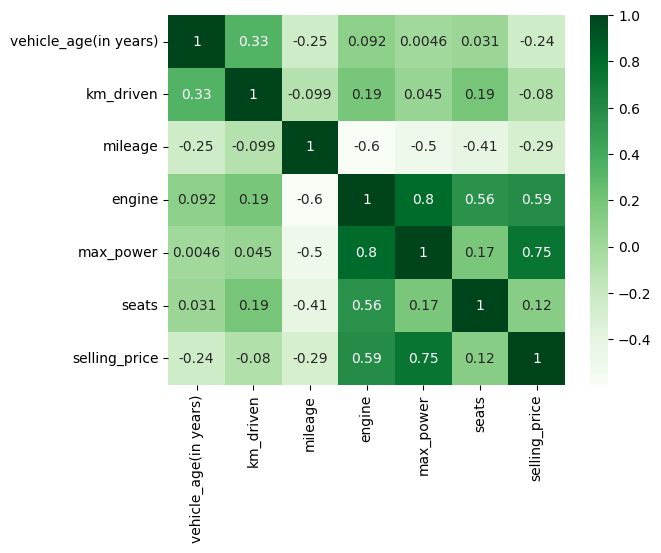

In [199]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cars.corr(numeric_only=True), annot=True, cmap='Greens')
plt.show()